# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from plotting_cs import *
from cross_sections import *
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', 20)

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('ref_dir')
ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp2000\00_empty_ref02"

In [3]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp1000\00_LP40_pristine"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [4]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2022\PSI22_04NI\Raw_images\exp2000\exp2200_LP40_deg\02_pos00\IMAT00018918_02_pos00_001_Spectra.txt"

#### Provide the directory for saving results

In [5]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\02_Cross_sections_results\000_exp1000"

### Read the directory and extract values from images
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [6]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  8.54it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [7]:
avg_imgs = []
for key, value in ref_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_img = 15, end_slice = 20)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [8]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')

# from each chip region LP30 pristine
ROIs_02_pos00 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_04_pos01 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 38], [145, 152, 78, 40]] #
ROIs_06_pos02 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_08_pos03 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_10_pos04 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]

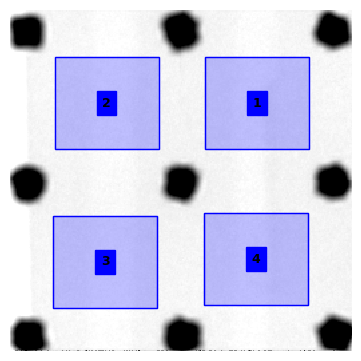

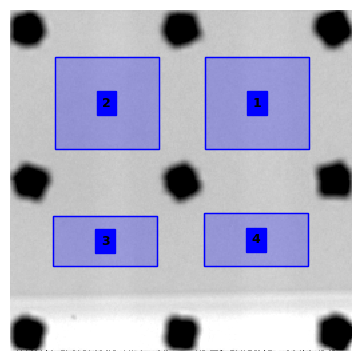

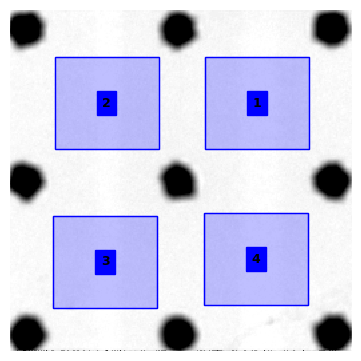

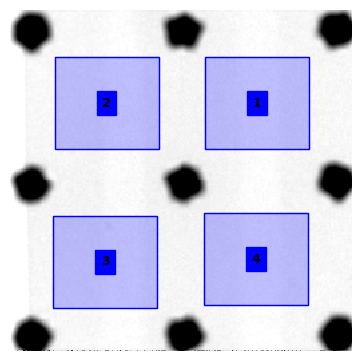

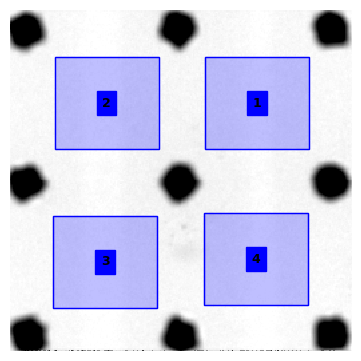

In [9]:
show_img(avg_imgs[0], dr = [(ROIs_02_pos00, 'blue')], cmap='gray', nrows=3, ncols=2, index=1)
show_img(avg_imgs[1], dr = [(ROIs_04_pos01, 'blue')], cmap='gray', nrows=3, ncols=2, index=2)
show_img(avg_imgs[2], dr = [(ROIs_06_pos02, 'blue')], cmap='gray', nrows=3, ncols=2, index=3)
show_img(avg_imgs[3], dr = [(ROIs_08_pos03, 'blue')], cmap='gray', nrows=3, ncols=2, index=4)
show_img(avg_imgs[4], dr = [(ROIs_10_pos04, 'blue')], cmap='gray', nrows=3, ncols=2, index=5)

#### Create a dictionary of the ROIs

In [10]:
rois_dict = {}
for name in ref_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [11]:
ref_vals = get_roi_values (ref_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [12]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [13]:
data_wvl = img_vals['Wavelength [Å]']

ref_vals = ref_vals.loc[2:36]
ref_vals = ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [14]:
trans_rois = prepare_trans_data(img_vals, data_ref = ref_vals, data_output = 'transmission')

In [15]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4,Transmission_04_pos01_roi_1,Transmission_04_pos01_roi_2,Transmission_04_pos01_roi_3,Transmission_04_pos01_roi_4,Transmission_06_pos02_roi_1,...,Transmission_06_pos02_roi_3,Transmission_06_pos02_roi_4,Transmission_08_pos03_roi_1,Transmission_08_pos03_roi_2,Transmission_08_pos03_roi_3,Transmission_08_pos03_roi_4,Transmission_10_pos04_roi_1,Transmission_10_pos04_roi_2,Transmission_10_pos04_roi_3,Transmission_10_pos04_roi_4
0,1.279359,0.876576,0.872900,0.870399,0.868872,0.881421,0.873441,0.878126,0.873696,0.870299,...,0.867199,0.870282,0.875329,0.877487,0.874107,0.875225,0.867880,0.870341,0.871698,0.873830
1,1.531952,0.867947,0.866248,0.867804,0.863005,0.870503,0.866305,0.869423,0.865774,0.861212,...,0.857028,0.860548,0.868129,0.867260,0.867992,0.861860,0.860614,0.864062,0.864014,0.863712
2,1.776463,0.855042,0.854739,0.857020,0.853346,0.859241,0.854840,0.859352,0.858493,0.852166,...,0.847629,0.848583,0.855373,0.856665,0.856626,0.851479,0.852891,0.854631,0.855757,0.854779
3,2.032233,0.846380,0.847227,0.849429,0.845902,0.851683,0.847443,0.851622,0.851290,0.837861,...,0.837734,0.837787,0.848228,0.848715,0.847716,0.845740,0.844203,0.847915,0.849352,0.847022
4,2.304880,0.839970,0.840660,0.844021,0.837789,0.842441,0.836980,0.843166,0.840435,0.833684,...,0.832276,0.833930,0.841606,0.843360,0.843329,0.839683,0.837434,0.840368,0.841542,0.839758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,8.806118,0.720050,0.718433,0.721417,0.717962,0.733216,0.722256,0.719632,0.723768,0.729603,...,0.724047,0.726985,0.725075,0.718833,0.721889,0.728624,0.714691,0.726457,0.718041,0.716474
31,9.039954,0.725307,0.731778,0.724515,0.724007,0.727432,0.722784,0.723019,0.731227,0.723720,...,0.720190,0.719292,0.718871,0.720181,0.715535,0.722133,0.708349,0.721012,0.727559,0.718622
32,9.271439,0.715076,0.703401,0.722350,0.721120,0.721621,0.716079,0.705326,0.715282,0.718112,...,0.707729,0.709960,0.720282,0.712005,0.702850,0.719523,0.720920,0.726353,0.723919,0.704736
33,9.525303,0.705704,0.711616,0.711115,0.714293,0.722501,0.708959,0.725352,0.723607,0.703409,...,0.708073,0.704644,0.720756,0.715417,0.697670,0.720110,0.708416,0.708290,0.715682,0.706483


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

### H cross section parameters

In [27]:
thickness = 0.06

ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#lp30 = {'abbv': 'LP30','molecules' : [ec, 0.501683056,dmc, 0.406359477, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
#lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}

lp30 = {'abbv': 'LP30','molecules' : [ec, 0.446003162,dmc, 0.446003162, lipf6, 0.107993676], 'density':1.2284, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.1847, 'thickness': thickness}

## exp2000 -> LP40


In [28]:
compounds_dict = [lp40, lp40, lp40, lp40, lp40, lp40, lp40, lp40, lp40, lp40,
                 lp40, lp40, lp40, lp40, lp40, lp40, lp40, lp40, lp40, lp40]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [29]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)

Data_imgs variable taken as transmission images


**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [30]:
#save_DF (dst_dir, res_data, df_name = '00_LP30_H_CS_pristine.xlsx', sheet_name = 'no_interp_lp30', mode = 'a')

In [31]:
res_data = dataframe_to_savgol(res_data, 5, 2)

In [32]:
save_DF (dst_dir, res_data, df_name = '00_LP40_H_CS.xlsx', sheet_name = 'LP40_pris_savgol_060', mode = 'a')

In [23]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]
pos01 = [column for column in res_data if 'pos01' in column]
pos02 = [column for column in res_data if 'pos02' in column]
pos03 = [column for column in res_data if 'pos03' in column]
pos04 = [column for column in res_data if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)
cs_pos01_dat = pd.concat([data_wvl, res_data[pos01]], axis = 1)
cs_pos02_dat = pd.concat([data_wvl, res_data[pos02]], axis = 1)
cs_pos03_dat = pd.concat([data_wvl, res_data[pos03]], axis = 1)
cs_pos04_dat = pd.concat([data_wvl, res_data[pos04]], axis = 1)

avg_vals_dat = pd.DataFrame(data_wvl)
avg_vals_dat ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos01'] = cs_pos01_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos02'] = cs_pos02_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos03'] = cs_pos03_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos04'] = cs_pos04_dat.iloc[:,1:].mean(axis=1)

In [24]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos01_dat=cs_pos01_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos02_dat=cs_pos02_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos03_dat=cs_pos03_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos04_dat=cs_pos04_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
avg_vals_dat=avg_vals_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

In [25]:
#sns.relplot(data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val', 
#            kind = 'line', legend = 'brief', height=6, aspect=1.2)

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

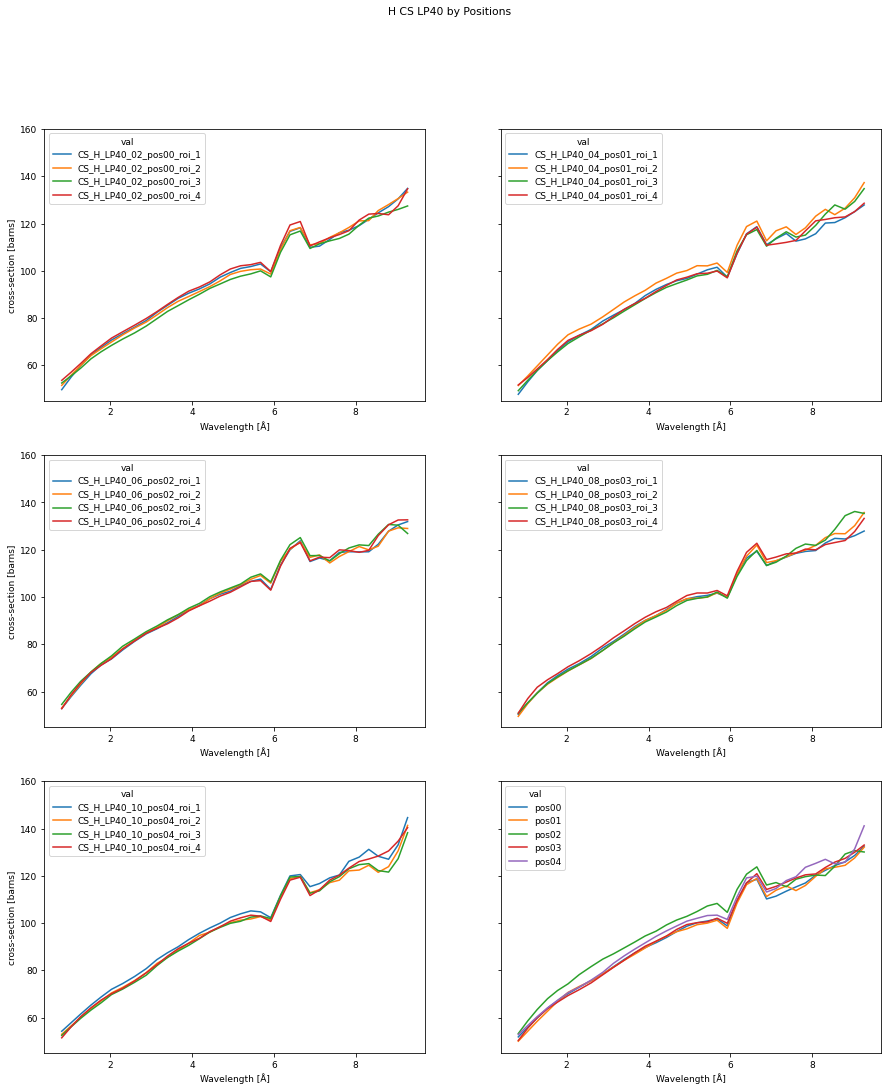

In [26]:
fig0, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig0.suptitle('H CS LP40 by Positions')
plt.ylim([45,160])
sns.lineplot(ax = ax[0,0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

### Normalize by 3A

In [ ]:
res_data_PEnorm = normalize_to_PE(res_data)

In [ ]:
res_data_PEn3Anorm = normalize_to_range(res_data_PEnorm, idx_range = [3,4])

In [ ]:
res_data_PEn3Anorm = dataframe_to_savgol(res_data_PEn3Anorm, 5, 1)

In [ ]:
    # position column name extraction
pos00 = [column for column in res_data_PEn3Anorm if 'pos00' in column]
pos01 = [column for column in res_data_PEn3Anorm if 'pos01' in column]
pos02 = [column for column in res_data_PEn3Anorm if 'pos02' in column]
pos03 = [column for column in res_data_PEn3Anorm if 'pos03' in column]
pos04 = [column for column in res_data_PEn3Anorm if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos00]], axis = 1)
cs_pos01_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos01]], axis = 1)
cs_pos02_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos02]], axis = 1)
cs_pos03_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos03]], axis = 1)
cs_pos04_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos04]], axis = 1)

avg_vals_norm = pd.DataFrame(data_wvl)
avg_vals_norm ['pos00'] = cs_pos00_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos01'] = cs_pos01_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos02'] = cs_pos02_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos03'] = cs_pos03_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos04'] = cs_pos04_norm.iloc[:,1:].mean(axis=1)

In [ ]:
#avg_vals = dataframe_to_savgol(avg_vals, 15, 1)

In [ ]:
cs_pos00_norm=cs_pos00_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos01_norm=cs_pos01_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos02_norm=cs_pos02_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos03_norm=cs_pos03_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos04_norm=cs_pos04_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
avg_vals_norm=avg_vals_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')

In [ ]:
fig1, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig1.suptitle('H CS Normalized LP30 Deg by Positions')
#ax[0,0].set_title('Pos00')
plt.ylim([0.85,1.6])
sns.lineplot(ax = ax[0,0], data = cs_pos00_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')

In [ ]:
res_data_PEn3Anorm